In [6]:
import pandas as pd

df = pd.read_csv("linear_regression_practice_dataset.csv")
df.head(10)

,feature_x,target_y
0,18.727006,NaN
1,47.535715,183.098382
2,36.599697,NaN
3,29.932924,NaN
4,7.800932,50.264465
5,7.799726,49.909594
6,2.904181,30.215767
7,43.308807,169.234954
8,30.055751,111.041420
9,35.403629,139.706248


In [7]:
print("Rows, columns:", df.shape)

Rows, columns: (130, 2)


In [12]:
print("\nMissing values\n", df.isnull().sum())


Missing values
 feature_x    13
target_y     13
dtype: int64


In [9]:
print("Dublicate rows", df.duplicated().sum())

Dublicate rows 10


Missing values visualization

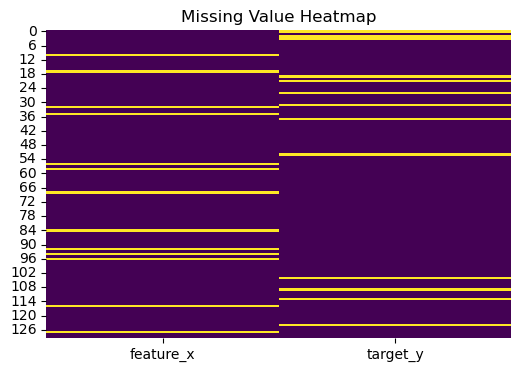

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Value Heatmap")
plt.show()

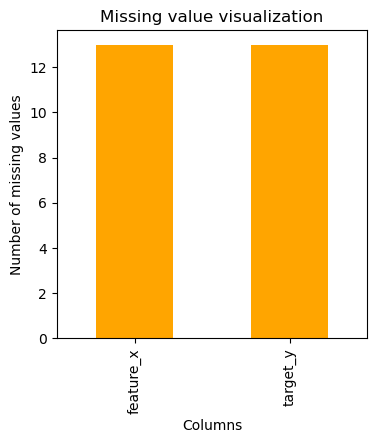

In [18]:
import matplotlib.pyplot as plt

valuecount = df.isnull().sum()

plt.figure(figsize=(4,4))
valuecount.plot(kind='bar', color='orange')
plt.title("Missing value visualization")
plt.xlabel("Columns")
plt.ylabel("Number of missing values")
plt.show()

In [20]:
df = df.drop_duplicates()
df.shape

(120, 2)

In [21]:
df = df.fillna(df.mean(numeric_only=True))
df.isnull().sum()

feature_x    0
target_y     0
dtype: int64

In [ ]:
# For dropping missing values
# df = df.dropna()

Text(0, 0.5, 'target_y')

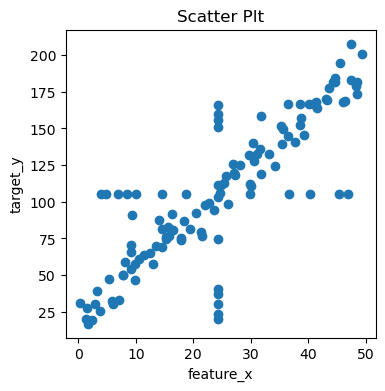

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(4,4))
plt.scatter(df['feature_x'], df['target_y'])
plt.title("Scatter Plt")
plt.xlabel("feature_x")
plt.ylabel("target_y")


In [26]:
from sklearn.model_selection import train_test_split

x= df[['feature_x']]
y = df['target_y']

X_train, X_test, Y_train, Y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [28]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, Y_train)

LinearRegression()

In [29]:
from sklearn.metrics import mean_squared_error, r2_score
Y_pred = model.predict(X_test)

mse = mean_squared_error(Y_test, Y_pred)
r2 = r2_score(Y_test, Y_pred)

print("MSE:", mse)
print('R2:', r2)
print("Coefficient: ", model.coef_[0])
print('Intercept:', model.intercept_)

MSE: 943.0113187343508
R2: 0.5522739868507058
Coefficient:  3.1447128036540906
Intercept: 28.440747944837327


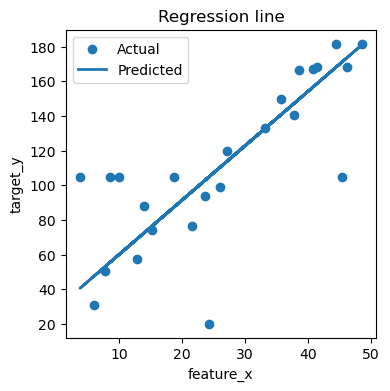

In [30]:
plt.figure(figsize=(4,4))
plt.scatter(X_test, Y_test, label="Actual")
plt.plot(X_test, Y_pred, label="Predicted", linewidth=2)
plt.xlabel("feature_x")
plt.ylabel("target_y")
plt.title("Regression line")
plt.legend()
plt.show()